In [2]:
import torch

from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(
    encoder="text_sonar_basic_encoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)
        
sonar_v2t = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)

def get_sonar_embedding(text):
    with torch.no_grad():
        embedding = sonar_t2v.predict([text], source_lang="eng_Latn")
    return embedding

## Std

In [3]:
import os
import json
import colorsys
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tqdm import tqdm
import matplotlib.pyplot as plt
from tqdm import tqdm 
import numpy as np


def read_json_files(directory, file_limit=None):
    texts = []
    labels = []
    i = 1
    for filename in os.listdir(directory):
        if file_limit and i >= file_limit:
            break
        if filename.endswith('.json'):
            with open(os.path.join(directory, filename), 'r') as file:
                data = json.load(file)
                file_texts = data.get('text', [])
                if len(file_texts) < 2:
                    continue
                if any(len(text.split()) < 3 for text in file_texts):
                    continue
                texts.extend(file_texts)
                labels.extend([i] * len(file_texts))
                i += 1
    return texts, labels


def calculate_embeddings(texts, method='sonar'):
    if method == 'sonar':
        embeddings = []
        for text in tqdm(texts):
            embedding = get_sonar_embedding(text)
            embeddings.append(embedding.squeeze().cpu().numpy())
    return np.array(embeddings)

In [4]:
directory = '../../dataset/reason_seg/ReasonSeg/test'
texts, labels = read_json_files(directory)# , file_limit=0)

In [5]:
len(texts)

3209

In [6]:
embeddings = calculate_embeddings(texts)

  0%|          | 0/3209 [00:00<?, ?it/s]

100%|██████████| 3209/3209 [00:33<00:00, 96.33it/s] 


In [7]:
import numpy as np

means = np.mean(embeddings, axis=0)  # shape: (1024,)
stds = np.std(embeddings, axis=0)    # shape: (1024,)

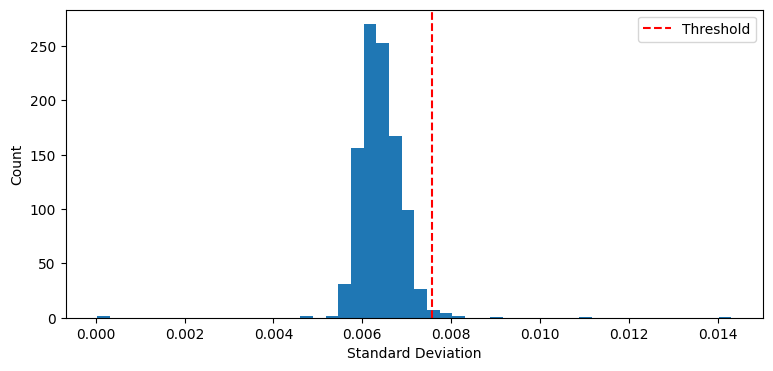

In [8]:
import matplotlib.pyplot as plt

std_of_stds = np.std(stds)
mean_of_stds = np.mean(stds)
threshold = mean_of_stds + 2 * std_of_stds
components_to_discard = np.where(stds >= threshold)[0]

plt.figure(figsize=(9, 4))
plt.hist(stds, bins=50)
plt.xlabel('Standard Deviation')
plt.ylabel('Count')
plt.axvline(x=threshold, color='r', linestyle='--', label='Threshold')
plt.legend()
plt.savefig('stds_hist.png')
plt.show()

/tmp/ipykernel_1805307/2112337268.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


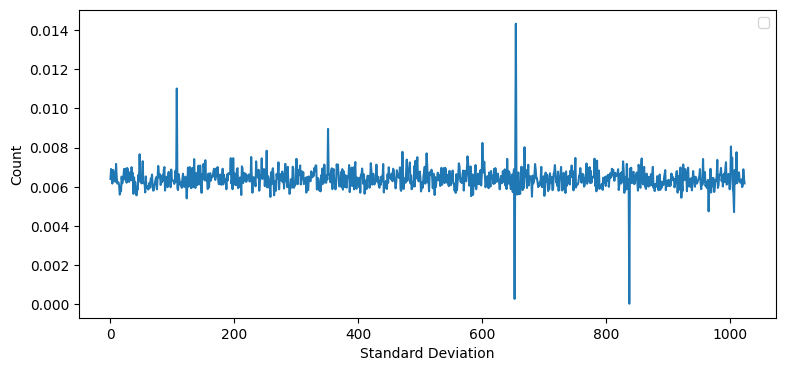

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(stds)
plt.xlabel('Standard Deviation')
plt.ylabel('Count')
plt.legend()
plt.savefig('stds.png')
plt.show()

### latent space

In [10]:
text = 'the region exhibiting unusual color'

In [11]:
embedding = get_sonar_embedding(text)
embedding.shape

torch.Size([1, 1024])

In [14]:
import torch
import numpy as np

def add_noise(embedding, noise_level=0.1):
    orig_embedding = embedding.clone()
    noise = torch.randn_like(embedding) * noise_level
    noisy_embedding = orig_embedding + noise
    noisy_embedding = noisy_embedding * (torch.norm(orig_embedding) / torch.norm(noisy_embedding))
    return noisy_embedding

noise_levels = [0.003, 0.004, 0.005, 0.006]

In [20]:
for noise_level in noise_levels:
    print('noise level: ', noise_level)
    for _ in range(1):
        noisy_embedding = add_noise(embedding, noise_level)
        text, _ = sonar_v2t.predict(noisy_embedding, target_lang="eng_Latn", max_seq_len=100)
        print(text)
    print('--------------------------------\n')

noise level:  0.003
['the region exhibiting an unusual color']
--------------------------------

noise level:  0.004
['the region exhibiting unusual color']
--------------------------------

noise level:  0.005
['the region that is exhibiting unusual color.']
--------------------------------

noise level:  0.006
['the region the cloud feing the unusual color of color has a unusual color']
--------------------------------

noise level:  0.007
['the region that ex un unusual color and unusual colo']
--------------------------------

noise level:  0.008
["The region's ex unusual color"]
--------------------------------

noise level:  0.009
['the cross ex exhibing in the, made unusual color the the normal']
--------------------------------

noise level:  0.01
['the region, exposed to the EG, is making an unusual coloring of heart.']
--------------------------------



In [22]:
text, probs = sonar_v2t.predict(embedding.clone(), target_lang="eng_Latn", max_seq_len=100)
text

['the region exhibiting unusual color']

In [23]:
probs

tensor([[6.0853e-07, 5.5145e-07, 4.6093e-07,  ..., 1.0647e-06, 2.5570e-08,
         1.0784e-08],
        [5.9728e-07, 6.9270e-07, 1.0910e-06,  ..., 2.3292e-06, 8.2907e-08,
         1.1296e-08],
        [3.0655e-07, 3.8731e-08, 4.8493e-07,  ..., 1.1029e-06, 8.9475e-08,
         5.3118e-08],
        ...,
        [2.7688e-07, 3.6026e-07, 7.9815e-08,  ..., 2.8839e-07, 3.0900e-08,
         5.3720e-09],
        [3.7450e-07, 3.5006e-07, 1.5040e-07,  ..., 7.1765e-07, 4.3450e-08,
         6.9754e-09],
        [5.7432e-07, 3.7548e-06, 4.9059e-07,  ..., 1.3391e-06, 9.1359e-08,
         1.1402e-07]], device='cuda:0', grad_fn=<SliceBackward0>)

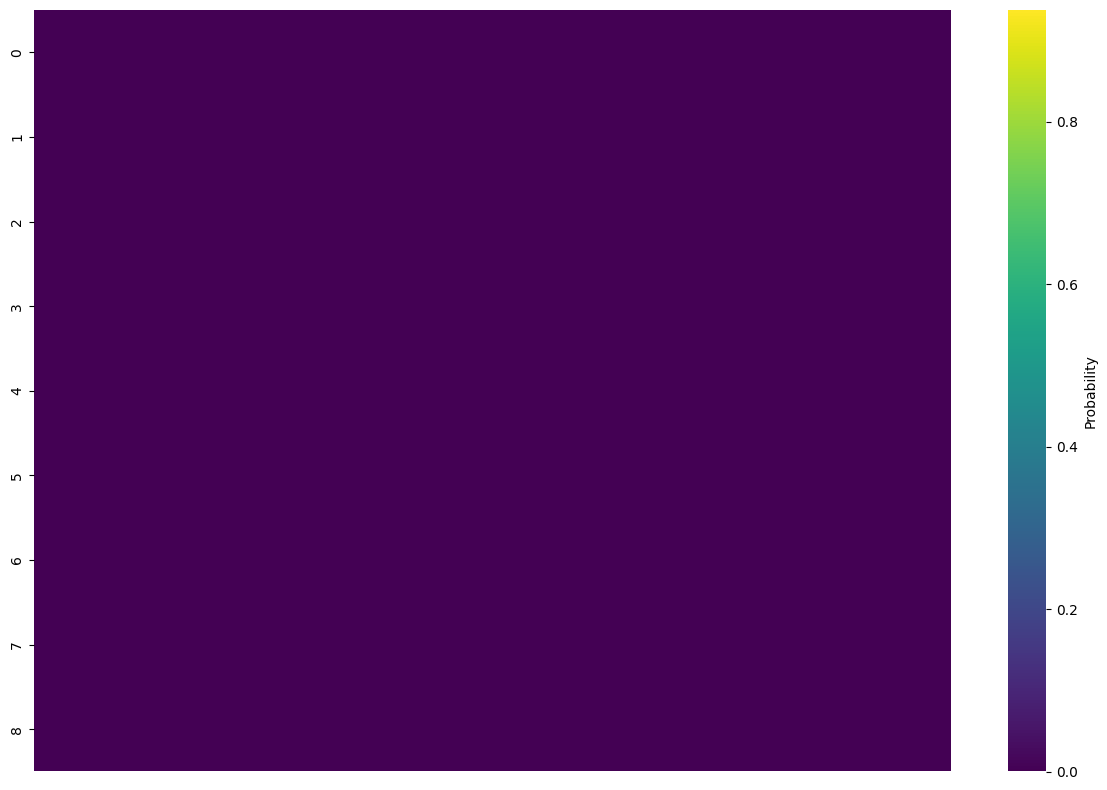

In [25]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(probs.detach().cpu().numpy(), xticklabels=False) 

plt.tight_layout()
plt.show()

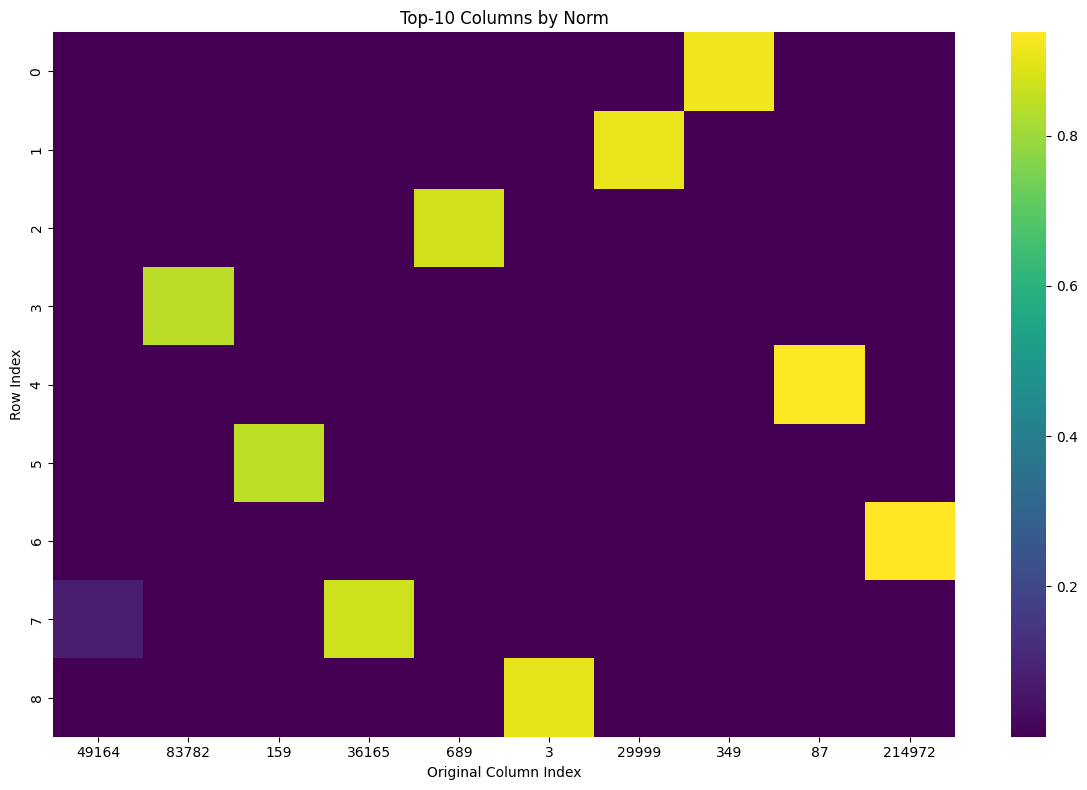

In [26]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy and get norms of columns
probs_np = probs.detach().cpu().numpy()
column_norms = np.linalg.norm(probs_np, axis=0)  # compute norm for each column

# Get indices of top-10 columns
top_10_cols = np.argsort(column_norms)[-10:]  # get indices of 10 highest norms

# Select only those columns
filtered_probs = probs_np[:, top_10_cols]

# Create y-axis labels (original row indices)
row_indices = np.arange(probs_np.shape[0])

plt.figure(figsize=(12, 8))

# Plot heatmap with row indices as y-labels
sns.heatmap(filtered_probs, 
            xticklabels=top_10_cols,  # Show original column indices
            yticklabels=row_indices,   # Show original row indices
            cmap='viridis')

plt.xlabel('Original Column Index')
plt.ylabel('Row Index')
plt.title('Top-10 Columns by Norm')

plt.tight_layout()
plt.show()

In [27]:
filtered_probs

array([[8.61520562e-07, 2.74313265e-07, 1.45271688e-05, 2.01379112e-06,
        2.36861115e-06, 5.56762563e-04, 8.02983050e-06, 9.16153073e-01,
        3.01257091e-06, 6.31618491e-07],
       [2.12562009e-06, 2.37387866e-07, 1.30149363e-06, 4.49617983e-06,
        2.79542746e-07, 5.43509377e-04, 9.06099617e-01, 9.17859870e-05,
        4.38118036e-07, 3.29512545e-07],
       [1.54006830e-06, 3.90848845e-06, 1.18950120e-05, 1.41399562e-06,
        8.71229768e-01, 3.32833704e-04, 4.30110489e-08, 6.24010227e-06,
        6.37775486e-07, 7.25998603e-08],
       [3.64083758e-06, 8.38727534e-01, 1.44533328e-06, 8.29583405e-06,
        8.13246661e-05, 2.04225697e-04, 6.83933621e-08, 1.16802294e-05,
        3.70188491e-06, 1.52790449e-06],
       [1.15443913e-06, 4.38759372e-07, 9.72592388e-05, 9.45902684e-07,
        3.89611705e-06, 2.72407400e-04, 1.08868939e-07, 1.03070481e-04,
        9.32086527e-01, 4.24780268e-07],
       [1.22720585e-05, 3.39818087e-07, 8.43676090e-01, 2.11418646e-05,
   